# 📊 Amazon Electronics - Advanced EDA

**348,228 Products** | **PostgreSQL Database** | **October 2025**

## Setup & Imports

In [1]:
# Install packages (run once, then restart kernel)
import sys
!{sys.executable} -m pip install wordcloud plotly scipy scikit-learn openpyxl -q
print("✅ Packages installed! Restart kernel now.")

✅ Packages installed! Restart kernel now.


In [2]:
import pandas as pd
import numpy as np
import psycopg2
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
plt.style.use('seaborn-v0_8-darkgrid')
print("✅ Libraries imported!")

✅ Libraries imported!


## 1. Load Data from PostgreSQL

In [3]:
conn = psycopg2.connect(
    host="localhost",
    database="amazon_electronics_rag",
    user="shivamsharma",
    port="5432"
)

query = """
SELECT parent_asin, title, description, features, average_rating, 
       rating_number, price, main_category, store, images, videos, blair_embedding
FROM products;
"""

df = pd.read_sql_query(query, conn)
conn.close()

print(f"✅ Loaded {len(df):,} products")
print(f"   Columns: {df.shape[1]}")
df.head(3)

/var/folders/k6/nc8bf2cd2t38l5jh4550613h0000gn/T/ipykernel_53768/2912125200.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


✅ Loaded 348,228 products
   Columns: 12


,parent_asin,title,description,features,average_rating,rating_number,price,main_category,store,images,videos,blair_embedding
0,B018JN8B9G,Novpeak 16G CZ Gem Clear Crystal Stainless Ste...,None,None,3.9,81,NaN,AMAZON FASHION,Novpeak,{'large': ['https://m.media-amazon.com/images/...,"{'url': [], 'title': [], 'user_id': []}","[0.33013558,0.18700129,-0.24780495,0.07573147,..."
1,B018JO21BE,bestseller2016 10pcs SMA RF Coax Connector Mal...,Product Type:SMA RF coax connector Gender: mal...,"Type: SMA Coax connector Gender:male plug,stra...",3.7,43,7.99,Home Audio & Theater,bestseller2016,{'large': ['https://m.media-amazon.com/images/...,{'url': ['https://www.amazon.com/vdp/0ab6ec718...,"[-0.053662367,0.102692634,-0.19574578,-0.36502..."
2,B018JR10LS,Silver Edition 15.5 x 21mm [704] c,None,None,4.7,27,NaN,Computers,VATH,{'large': ['https://m.media-amazon.com/images/...,"{'url': [], 'title': [], 'user_id': []}","[-0.030980183,0.201803,0.20141377,-0.029196622..."


## 2. Feature Engineering - Create New Features

In [4]:
print("🔧 Creating 10+ new features...\n")

# Price segments
df['price_segment'] = pd.cut(
    df['price'], 
    bins=[0, 20, 50, 100, 200, 500, 10000], 
    labels=['Budget (<$20)', 'Low ($20-50)', 'Mid ($50-100)', 
            'Mid-High ($100-200)', 'High ($200-500)', 'Premium (>$500)']
)

# Rating categories
df['rating_category'] = pd.cut(
    df['average_rating'],
    bins=[0, 3.0, 3.5, 4.0, 4.5, 5.0],
    labels=['Poor (<3)', 'Below Avg (3-3.5)', 'Average (3.5-4)', 
            'Good (4-4.5)', 'Excellent (4.5-5)']
)

# Review volume
df['review_volume'] = pd.cut(
    df['rating_number'],
    bins=[-1, 10, 50, 200, 1000, 100000],
    labels=['Very Low (<10)', 'Low (10-50)', 'Medium (50-200)', 
            'High (200-1K)', 'Very High (>1K)']
)

# Text metrics
df['title_length'] = df['title'].str.len()
df['title_word_count'] = df['title'].str.split().str.len()
df['potential_brand'] = df['title'].str.split().str[0]

# Popularity score (composite: 60% reviews + 40% rating)
scaler = MinMaxScaler()
df['popularity_score'] = (
    scaler.fit_transform(df[['rating_number']].fillna(0)) * 0.6 +
    scaler.fit_transform(df[['average_rating']].fillna(0)) * 0.4
).flatten()

# Value metric (lower = better deal)
df['price_per_rating'] = df['price'] / (df['average_rating'] + 0.01)

print("✅ Created features:")
for f in ['price_segment', 'rating_category', 'review_volume', 'popularity_score', 
          'price_per_rating', 'potential_brand', 'title_length']:
    print(f"   • {f}")
    
print(f"\n📊 Dataset now has {df.shape[1]} columns")

🔧 Creating 10+ new features...

✅ Created features:
   • price_segment
   • rating_category
   • review_volume
   • popularity_score
   • price_per_rating
   • potential_brand
   • title_length

📊 Dataset now has 20 columns


## 3. Price Segment Analysis

/var/folders/k6/nc8bf2cd2t38l5jh4550613h0000gn/T/ipykernel_53768/2997050093.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_rating = df.groupby('price_segment')['average_rating'].mean().sort_index()
/var/folders/k6/nc8bf2cd2t38l5jh4550613h0000gn/T/ipykernel_53768/2997050093.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_reviews = df.groupby('price_segment')['rating_number'].median().sort_index()


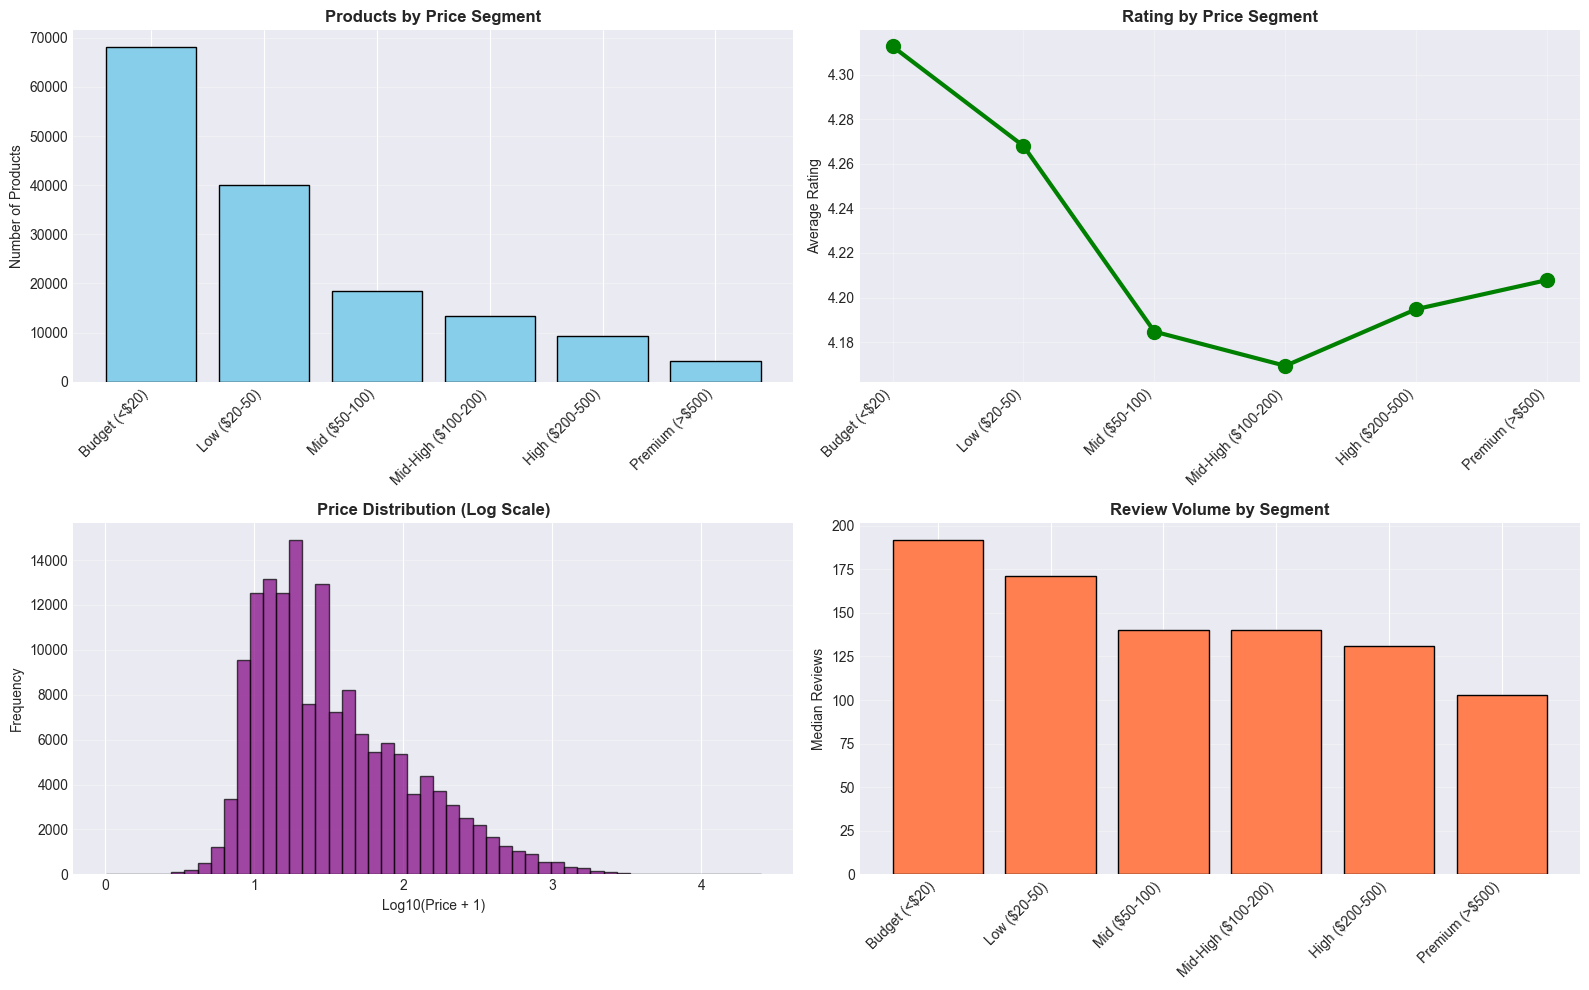


💰 Most common: Budget (<$20) (68,075 products)
⭐ Highest rated: Budget (<$20) (4.31★)


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Products per segment
price_counts = df['price_segment'].value_counts().sort_index()
axes[0,0].bar(range(len(price_counts)), price_counts.values, color='skyblue', edgecolor='black')
axes[0,0].set_xticks(range(len(price_counts)))
axes[0,0].set_xticklabels(price_counts.index, rotation=45, ha='right')
axes[0,0].set_ylabel('Number of Products')
axes[0,0].set_title('Products by Price Segment', fontweight='bold')
axes[0,0].grid(axis='y', alpha=0.3)

# Rating by segment
price_rating = df.groupby('price_segment')['average_rating'].mean().sort_index()
axes[0,1].plot(range(len(price_rating)), price_rating.values, marker='o', linewidth=3, markersize=10, color='green')
axes[0,1].set_xticks(range(len(price_rating)))
axes[0,1].set_xticklabels(price_rating.index, rotation=45, ha='right')
axes[0,1].set_ylabel('Average Rating')
axes[0,1].set_title('Rating by Price Segment', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# Price distribution (log)
valid_prices = df['price'].dropna()
axes[1,0].hist(np.log10(valid_prices + 1), bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1,0].set_xlabel('Log10(Price + 1)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Price Distribution (Log Scale)', fontweight='bold')
axes[1,0].grid(axis='y', alpha=0.3)

# Reviews by segment
price_reviews = df.groupby('price_segment')['rating_number'].median().sort_index()
axes[1,1].bar(range(len(price_reviews)), price_reviews.values, color='coral', edgecolor='black')
axes[1,1].set_xticks(range(len(price_reviews)))
axes[1,1].set_xticklabels(price_reviews.index, rotation=45, ha='right')
axes[1,1].set_ylabel('Median Reviews')
axes[1,1].set_title('Review Volume by Segment', fontweight='bold')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💰 Most common: {price_counts.idxmax()} ({price_counts.max():,} products)")
print(f"⭐ Highest rated: {price_rating.idxmax()} ({price_rating.max():.2f}★)")

## 4. Brand Analysis

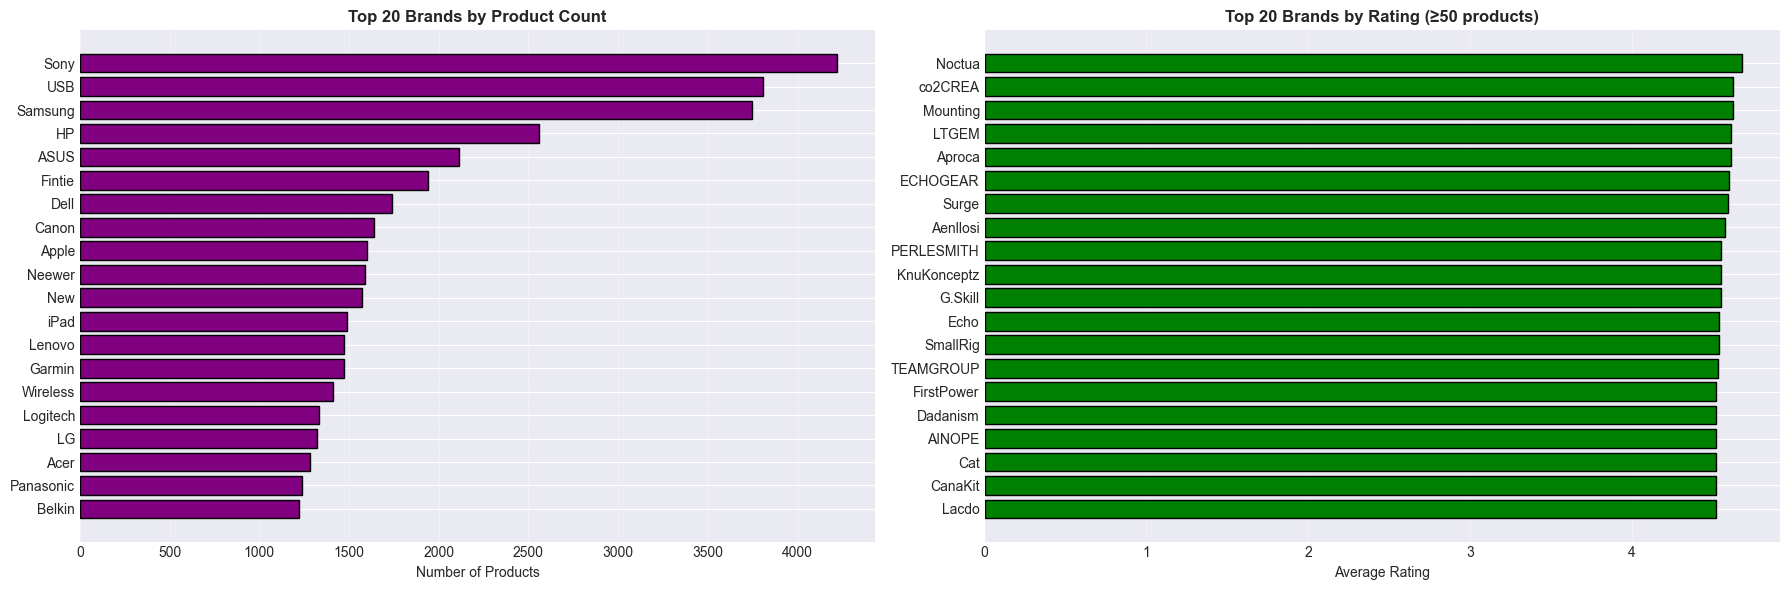


🏆 Most products: Sony (4,222)
🌟 Highest rated: Noctua (4.68★)
🏷️  Total brands: 44,838


In [6]:
top_brands = df['potential_brand'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top brands by count
axes[0].barh(range(len(top_brands)), top_brands.values, color='purple', edgecolor='black')
axes[0].set_yticks(range(len(top_brands)))
axes[0].set_yticklabels(top_brands.index)
axes[0].set_xlabel('Number of Products')
axes[0].set_title('Top 20 Brands by Product Count', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Top brands by rating
brand_ratings = df.groupby('potential_brand').agg({
    'average_rating': 'mean',
    'parent_asin': 'count'
}).rename(columns={'parent_asin': 'count'})
brand_ratings = brand_ratings[brand_ratings['count'] >= 50]
top_rated = brand_ratings.nlargest(20, 'average_rating')

axes[1].barh(range(len(top_rated)), top_rated['average_rating'].values, color='green', edgecolor='black')
axes[1].set_yticks(range(len(top_rated)))
axes[1].set_yticklabels(top_rated.index)
axes[1].set_xlabel('Average Rating')
axes[1].set_title('Top 20 Brands by Rating (≥50 products)', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🏆 Most products: {top_brands.index[0]} ({top_brands.values[0]:,})")
print(f"🌟 Highest rated: {top_rated.index[0]} ({top_rated.iloc[0]['average_rating']:.2f}★)")
print(f"🏷️  Total brands: {df['potential_brand'].nunique():,}")

## 5. TF-IDF Keyword Analysis

📝 Analyzing keywords...

Top 20 Keywords by TF-IDF:

 1. black                              20,844.1
 2. usb                                18,731.8
 3. case                               16,509.8
 4. cable                              16,031.1
 5. camera                             14,812.7
 6. inch                               13,755.2
 7. adapter                            12,269.1
 8. compatible                         11,613.4
 9. wireless                           11,107.9
10. laptop                             11,104.9
11. power                              10,580.5
12. pro                                10,506.2
13. pack                               10,040.9
14. 10                                  9,747.7
15. battery                             9,556.2
16. ipad                                9,044.1
17. bluetooth                           9,040.0
18. mount                               8,389.9
19. replacement                         8,313.9
20. digital                        

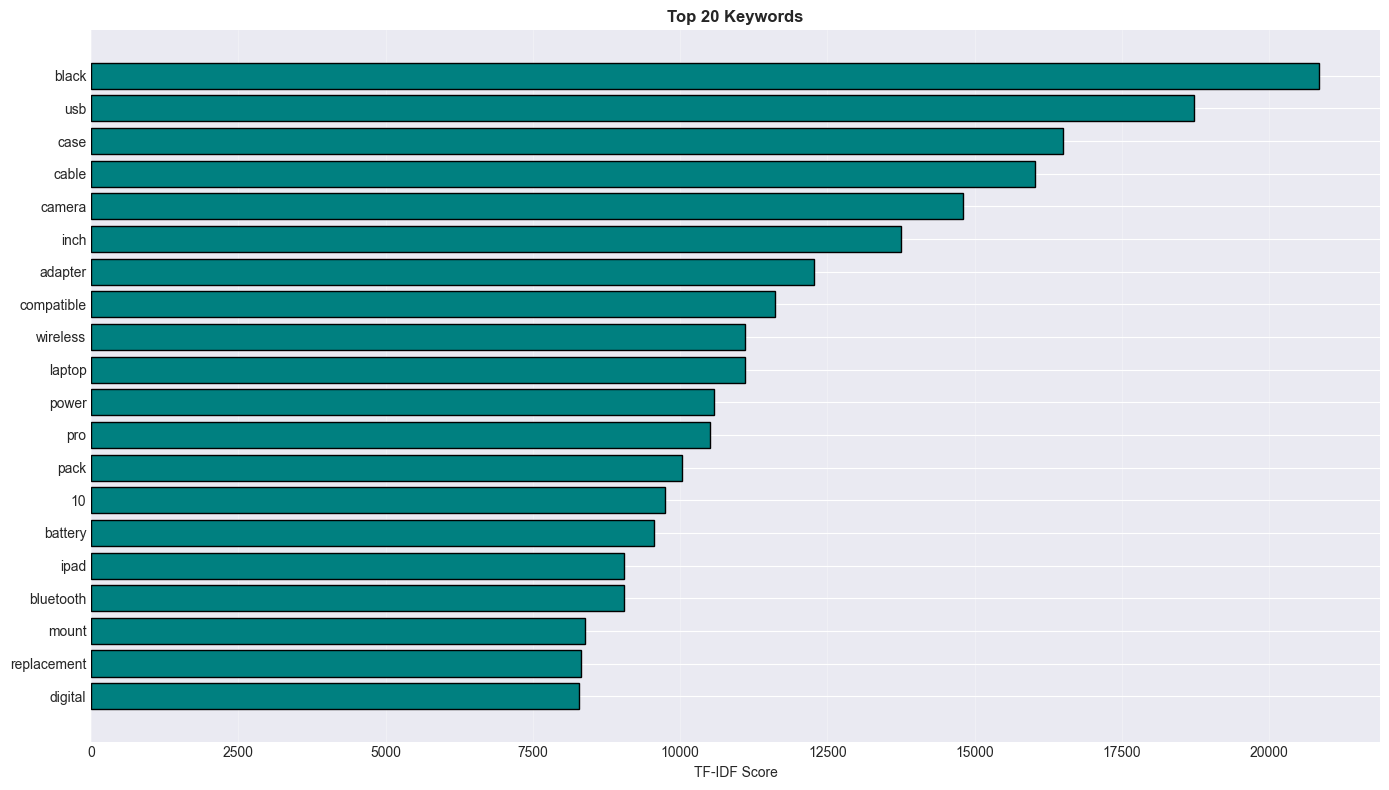

In [7]:
print("📝 Analyzing keywords...\n")

titles = df['title'].fillna('').str.lower()
tfidf = TfidfVectorizer(max_features=100, stop_words='english', ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(titles)

feature_names = tfidf.get_feature_names_out()
tfidf_scores = tfidf_matrix.sum(axis=0).A1
top_terms = sorted(zip(feature_names, tfidf_scores), key=lambda x: x[1], reverse=True)[:20]

print("Top 20 Keywords by TF-IDF:\n")
for i, (term, score) in enumerate(top_terms, 1):
    print(f"{i:2d}. {term:30s} {score:12,.1f}")

# Visualize
terms, scores = zip(*top_terms)
plt.figure(figsize=(14, 8))
plt.barh(range(len(terms)), scores, color='teal', edgecolor='black')
plt.yticks(range(len(terms)), terms)
plt.xlabel('TF-IDF Score')
plt.title('Top 20 Keywords', fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Popularity & Value Analysis

/var/folders/k6/nc8bf2cd2t38l5jh4550613h0000gn/T/ipykernel_53768/4164780718.py:24: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


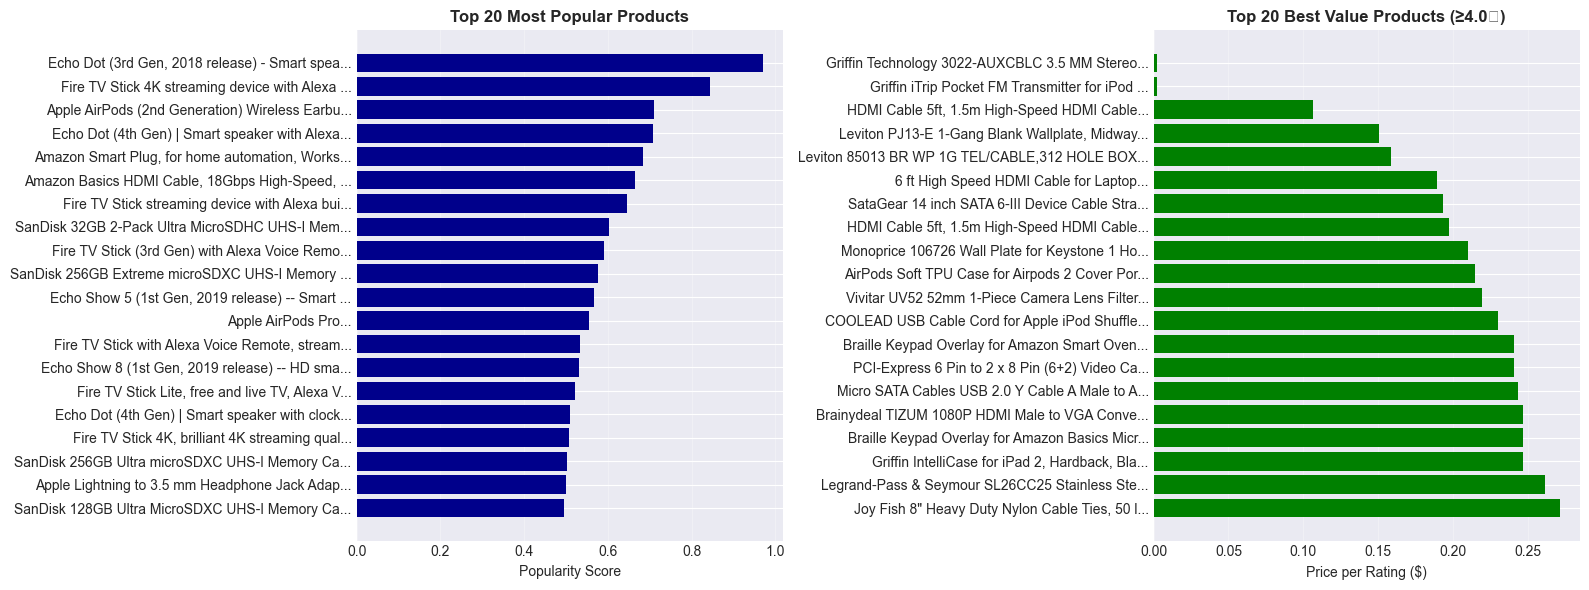


🌟 Most popular: Echo Dot (3rd Gen, 2018 release) - Smart speaker with Alexa - Charcoal...
💎 Best value: Griffin Technology 3022-AUXCBLC 3.5 MM Stereo Audio Cable (Discontinue...


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Most popular
top_popular = df.nlargest(20, 'popularity_score')[['title', 'popularity_score']]
axes[0].barh(range(len(top_popular)), top_popular['popularity_score'].values, color='darkblue')
axes[0].set_yticks(range(len(top_popular)))
axes[0].set_yticklabels([t[:45] + '...' for t in top_popular['title']])
axes[0].set_xlabel('Popularity Score')
axes[0].set_title('Top 20 Most Popular Products', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Best value
high_rated = df[df['average_rating'] >= 4.0].copy()
best_value = high_rated.nsmallest(20, 'price_per_rating')[['title', 'price_per_rating']]
axes[1].barh(range(len(best_value)), best_value['price_per_rating'].values, color='green')
axes[1].set_yticks(range(len(best_value)))
axes[1].set_yticklabels([t[:45] + '...' for t in best_value['title']])
axes[1].set_xlabel('Price per Rating ($)')
axes[1].set_title('Top 20 Best Value Products (≥4.0★)', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🌟 Most popular: {df.loc[df['popularity_score'].idxmax(), 'title'][:70]}...")
print(f"💎 Best value: {best_value.iloc[0]['title'][:70]}...")

## 7. Feature Correlation Matrix

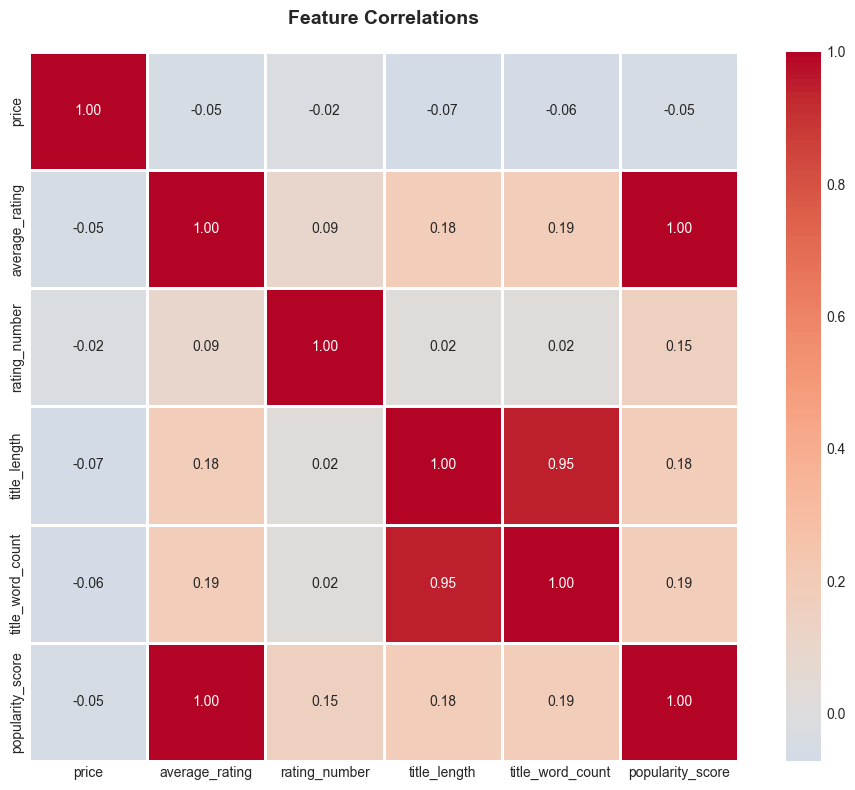


Strongest correlations (|r| > 0.3):
   average_rating       <-> popularity_score       r = +0.998
   title_length         <-> title_word_count       r = +0.949


In [9]:
features = ['price', 'average_rating', 'rating_number', 'title_length', 
            'title_word_count', 'popularity_score']

corr = df[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Feature Correlations', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\nStrongest correlations (|r| > 0.3):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.3:
            print(f"   {corr.columns[i]:20s} <-> {corr.columns[j]:20s}   r = {corr.iloc[i, j]:+.3f}")

## 8. Export Results

In [10]:
print("💾 Exporting results...\n")

# Enhanced dataset sample
export_cols = ['parent_asin', 'title', 'price', 'average_rating', 'rating_number',
               'price_segment', 'rating_category', 'popularity_score', 
               'potential_brand', 'price_per_rating']
df[export_cols].head(5000).to_csv('products_enhanced.csv', index=False)
print("✅ products_enhanced.csv (5,000 products)")

# Top brands
top_brands.to_csv('top_brands.csv')
print("✅ top_brands.csv")

# Summary
print(f"\n{'='*60}")
print(f"📊 SUMMARY")
print(f"{'='*60}")
print(f"Total products: {len(df):,}")
print(f"Median price: ${df['price'].median():.2f}")
print(f"Average rating: {df['average_rating'].mean():.2f}★")
print(f"Unique brands: {df['potential_brand'].nunique():,}")
print(f"Categories: {df['main_category'].nunique()}")
print(f"{'='*60}")

💾 Exporting results...

✅ products_enhanced.csv (5,000 products)
✅ top_brands.csv

📊 SUMMARY
Total products: 348,228
Median price: $24.99
Average rating: 4.08★
Unique brands: 44,838
Categories: 38
